# Week 1 Data Engineering: Simple Standardization

**Author:** Zihao Huang (Role 2, Data Engineer)
**Project:** Face-to-BMI Replication

## Approach

Since the VisualBMI images are already face-centered by the dataset authors,
running face detection and alignment on them adds more artifacts than signal.
This notebook takes the simpler approach:

1. Pad each image to a square with black bars on the shorter sides
2. Resize the square to $224 \times 224$

This preserves the original face proportions exactly (no stretching) and uses
the minimum amount of black padding possible.

## What this notebook produces

1. `data/processed/audit_log.csv`: per-image dimensions and metadata (useful
   for Junny's EDA report).
2. `data/processed/faces_standardized/`: all images padded and resized to
   $224 \times 224$ RGB BMP files.
3. `data/processed/standardization_log.csv`: status per image (ok, missing,
   error) joined with bmi, gender, and is_training for downstream use.


## Step 0: Mount Google Drive and set paths

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi'

RAW_IMAGES_DIR = os.path.join(PROJECT_ROOT, 'data/raw/images')
RAW_CSV_PATH   = os.path.join(PROJECT_ROOT, 'data/raw/data.csv')

PROCESSED_DIR             = os.path.join(PROJECT_ROOT, 'data/processed')
FACES_OUT_DIR             = os.path.join(PROCESSED_DIR, 'faces_standardized')
AUDIT_LOG_PATH            = os.path.join(PROCESSED_DIR, 'audit_log.csv')
STANDARDIZATION_LOG_PATH  = os.path.join(PROCESSED_DIR, 'standardization_log.csv')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FACES_OUT_DIR, exist_ok=True)

assert os.path.exists(RAW_IMAGES_DIR), f'Images dir not found: {RAW_IMAGES_DIR}'
assert os.path.exists(RAW_CSV_PATH),   f'CSV not found: {RAW_CSV_PATH}'

print('Paths OK')
print(f'  Raw images: {RAW_IMAGES_DIR}')
print(f'  Output dir: {FACES_OUT_DIR}')


Mounted at /content/drive
Paths OK
  Raw images: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/raw/images
  Output dir: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/faces_standardized


## Step 1: Install dependencies

In [2]:
!pip install -q pillow pandas tqdm matplotlib numpy


## Step 2: Copy raw images to local disk

Drive I/O is slow. Copying once makes the rest of the notebook fast.


In [3]:
import shutil, time

LOCAL_IMAGES_DIR = '/content/raw_images'

if not os.path.exists(LOCAL_IMAGES_DIR) or len(os.listdir(LOCAL_IMAGES_DIR)) == 0:
    print('Copying raw images to local disk...')
    t0 = time.time()
    shutil.copytree(RAW_IMAGES_DIR, LOCAL_IMAGES_DIR, dirs_exist_ok=True)
    print(f'Copied {len(os.listdir(LOCAL_IMAGES_DIR))} files in {time.time()-t0:.1f}s')
else:
    print(f'Already cached: {len(os.listdir(LOCAL_IMAGES_DIR))} files')


Copying raw images to local disk...
Copied 3965 files in 360.2s


## Step 3: Audit the raw images

Records dimensions, color mode, and file size for every image. This is useful
context for Junny's EDA report and for understanding the dataset.


In [4]:
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

metadata = pd.read_csv(RAW_CSV_PATH)
print(f'Metadata rows: {len(metadata)}')
print(metadata.head(3))


Metadata rows: 4206
   Unnamed: 0        bmi  gender  is_training       name
0           0  34.207396    Male            1  img_0.bmp
1           1  26.453720    Male            1  img_1.bmp
2           2  34.967561  Female            1  img_2.bmp


In [5]:
audit_rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='Auditing'):
    name = row['name']
    path = os.path.join(LOCAL_IMAGES_DIR, name)

    rec = {
        'name': name,
        'exists': os.path.exists(path),
        'width': None, 'height': None,
        'file_size_kb': None, 'mode': None,
        'aspect_ratio': None,
    }

    if not rec['exists']:
        audit_rows.append(rec)
        continue

    try:
        rec['file_size_kb'] = round(os.path.getsize(path) / 1024, 1)
        img = Image.open(path)
        rec['width'], rec['height'] = img.size
        rec['mode'] = img.mode
        rec['aspect_ratio'] = round(img.size[0] / img.size[1], 3)
    except Exception as exc:
        rec['mode'] = f'ERROR: {exc}'

    audit_rows.append(rec)

audit_df = pd.DataFrame(audit_rows)
audit_df = audit_df.merge(
    metadata[['name', 'bmi', 'gender', 'is_training']], on='name', how='left'
)
audit_df.to_csv(AUDIT_LOG_PATH, index=False)
print(f'Saved audit log: {AUDIT_LOG_PATH}')
audit_df.head()


Auditing:   0%|          | 0/4206 [00:00<?, ?it/s]

Saved audit log: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/audit_log.csv


,name,exists,width,height,file_size_kb,mode,aspect_ratio,bmi,gender,is_training
0,img_0.bmp,True,164.0,176.0,84.6,RGB,0.932,34.207396,Male,1
1,img_1.bmp,True,150.0,173.0,76.4,RGB,0.867,26.453720,Male,1
2,img_2.bmp,True,226.0,251.0,166.7,RGB,0.900,34.967561,Female,1
3,img_3.bmp,True,97.0,126.0,36.0,RGB,0.770,22.044766,Female,1
4,img_4.bmp,False,NaN,NaN,NaN,None,NaN,37.758789,Female,1


## Step 4: Audit summary

In [6]:
print('=== DIMENSIONS ===')
print(audit_df[['width', 'height', 'file_size_kb', 'aspect_ratio']].describe().round(2))

print('\n=== COLOR MODE ===')
print(audit_df['mode'].value_counts())

print('\n=== FILE AVAILABILITY ===')
total   = len(audit_df)
exists  = audit_df['exists'].sum()
missing = total - exists
print(f'On disk:           {exists} ({100*exists/total:.1f}%)')
print(f'Missing from disk: {missing} ({100*missing/total:.1f}%)')

print('\n=== ASPECT RATIOS ===')
portrait = ((audit_df['aspect_ratio'] < 0.95) & audit_df['exists']).sum()
square   = (audit_df['aspect_ratio'].between(0.95, 1.05) & audit_df['exists']).sum()
landscape= ((audit_df['aspect_ratio'] > 1.05) & audit_df['exists']).sum()
print(f'Portrait (taller than wide): {portrait}')
print(f'Nearly square:               {square}')
print(f'Landscape (wider than tall): {landscape}')


=== DIMENSIONS ===
         width   height  file_size_kb  aspect_ratio
count  3962.00  3962.00       3962.00       3962.00
mean    293.39   364.52        426.36          0.82
std     170.87   221.00        499.63          0.10
min      41.00    52.00          6.30          0.50
25%     159.00   193.00         92.40          0.75
50%     249.00   306.00        229.55          0.81
75%     392.00   482.00        556.98          0.88
max     900.00  1222.00       3016.90          1.29

=== COLOR MODE ===
mode
RGB    3954
P         8
Name: count, dtype: int64

=== FILE AVAILABILITY ===
On disk:           3962 (94.2%)
Missing from disk: 244 (5.8%)

=== ASPECT RATIOS ===
Portrait (taller than wide): 3581
Nearly square:               318
Landscape (wider than tall): 63


### Visualize the distributions

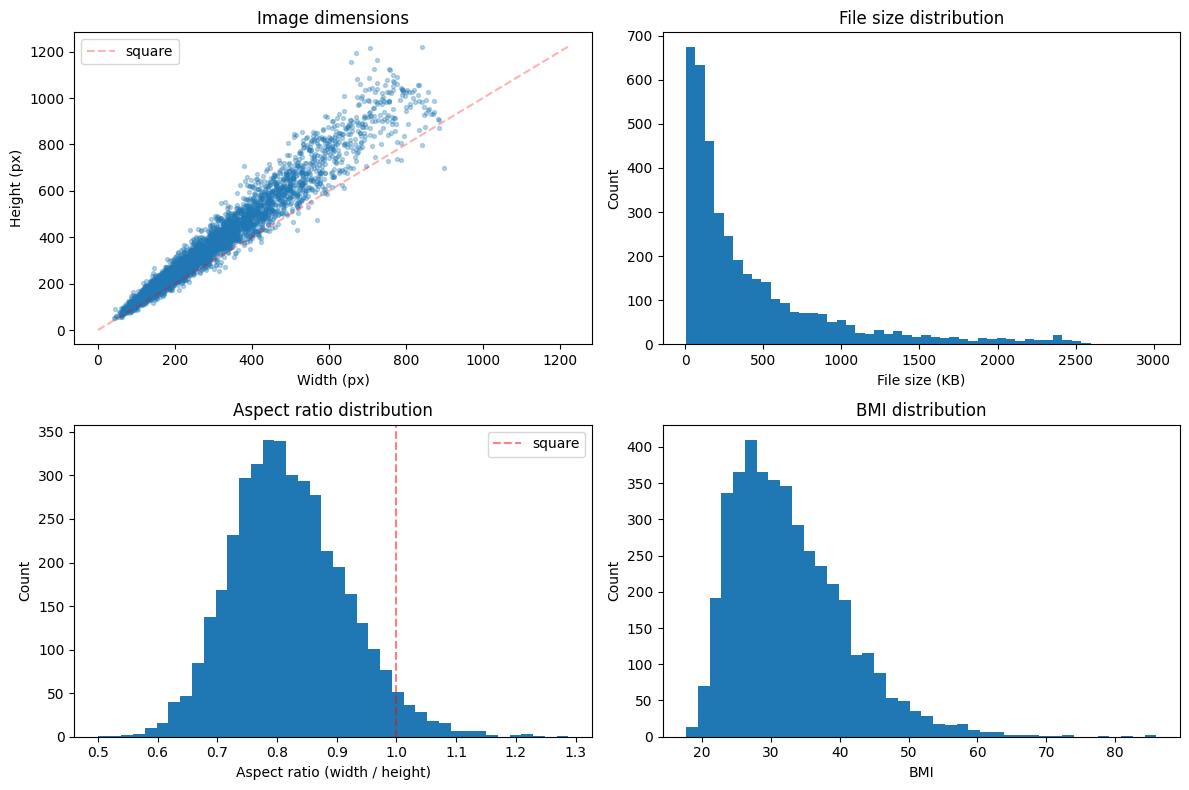

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(audit_df['width'], audit_df['height'], alpha=0.3, s=8)
axes[0, 0].set_xlabel('Width (px)')
axes[0, 0].set_ylabel('Height (px)')
axes[0, 0].set_title('Image dimensions')
# Reference line for perfect square
lim = max(audit_df['width'].max(), audit_df['height'].max())
axes[0, 0].plot([0, lim], [0, lim], 'r--', alpha=0.3, label='square')
axes[0, 0].legend()

axes[0, 1].hist(audit_df['file_size_kb'].dropna(), bins=50)
axes[0, 1].set_xlabel('File size (KB)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('File size distribution')

axes[1, 0].hist(audit_df['aspect_ratio'].dropna(), bins=40)
axes[1, 0].set_xlabel('Aspect ratio (width / height)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Aspect ratio distribution')
axes[1, 0].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='square')
axes[1, 0].legend()

axes[1, 1].hist(audit_df['bmi'].dropna(), bins=40)
axes[1, 1].set_xlabel('BMI')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('BMI distribution')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'audit_distributions.png'), dpi=120)
plt.show()


## Step 5: Standardize (pad to square, then resize)

For each image:

1. Load and convert to RGB
2. Create a square black canvas with side equal to the longer dimension
3. Paste the image centered in the canvas (black bars appear on the shorter sides)
4. Resize the square canvas to $224 \times 224$

This preserves the original aspect ratio and face proportions exactly.


In [8]:
OUTPUT_SIZE = 224


def pad_and_resize(pil_img, output_size=OUTPUT_SIZE, fill=(0, 0, 0)):
    """Pad the image to a square with black bars, then resize to output_size.

    Aspect ratio of the original is preserved exactly. Face proportions do not
    change. The final resize is square to square so there is no stretching.
    """
    img = pil_img.convert('RGB')
    w, h = img.size
    side = max(w, h)

    # Create square canvas and paste the image centered on it.
    canvas = Image.new('RGB', (side, side), fill)
    offset = ((side - w) // 2, (side - h) // 2)
    canvas.paste(img, offset)

    return canvas.resize((output_size, output_size), Image.LANCZOS)


standardization_rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='Standardizing'):
    name = row['name']
    in_path  = os.path.join(LOCAL_IMAGES_DIR, name)
    out_path = os.path.join(FACES_OUT_DIR, name)

    rec = {'name': name, 'status': None, 'notes': ''}

    if not os.path.exists(in_path):
        rec['status'] = 'missing_input'
        standardization_rows.append(rec)
        continue

    try:
        img = Image.open(in_path)
        out = pad_and_resize(img)
        out.save(out_path, format='BMP')
        rec['status'] = 'ok'
    except Exception as exc:
        rec['status'] = 'error'
        rec['notes'] = str(exc)

    standardization_rows.append(rec)

standardization_df = pd.DataFrame(standardization_rows)
standardization_df = standardization_df.merge(
    metadata[['name', 'bmi', 'gender', 'is_training']], on='name', how='left'
)
standardization_df.to_csv(STANDARDIZATION_LOG_PATH, index=False)
print(f'Saved log: {STANDARDIZATION_LOG_PATH}')
standardization_df['status'].value_counts()


Standardizing:   0%|          | 0/4206 [00:00<?, ?it/s]

Saved log: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/standardization_log.csv


,count
status,
ok,3962
missing_input,244


## Step 6: Visual sanity check

Compare before and after for 12 random images. The "after" should show the same
image as the "before" with equal black bars on two sides (top and bottom for
portrait originals, left and right for landscape originals). Face proportions
should look identical.


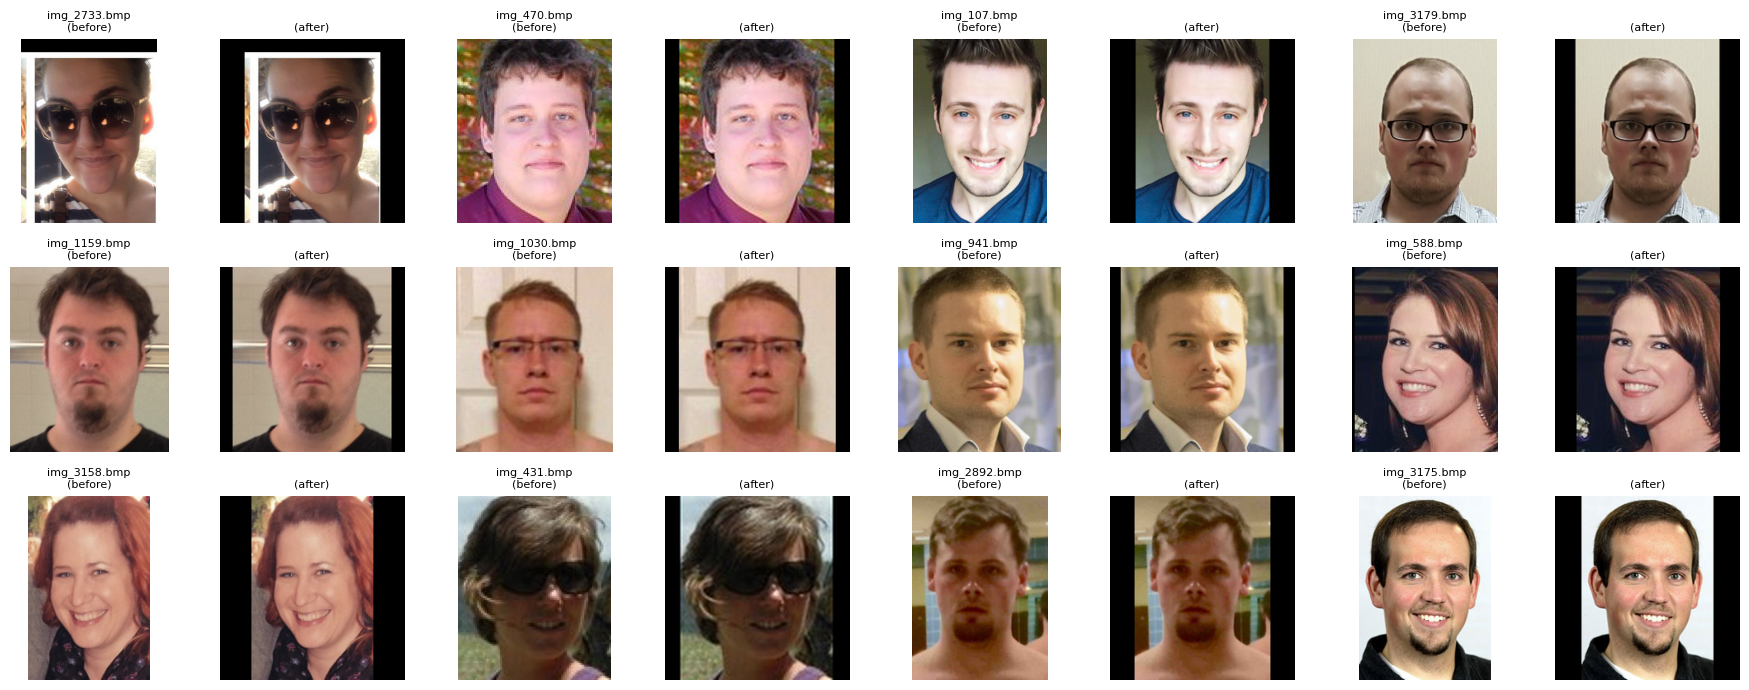

In [9]:
import random

random.seed(42)
ok_names = standardization_df[standardization_df['status'] == 'ok']['name'].tolist()
sample_names = random.sample(ok_names, min(12, len(ok_names)))

fig, axes = plt.subplots(3, 8, figsize=(18, 7))
for i, name in enumerate(sample_names):
    col_before = (i % 4) * 2
    col_after  = col_before + 1
    r = i // 4

    before = Image.open(os.path.join(LOCAL_IMAGES_DIR, name))
    after  = Image.open(os.path.join(FACES_OUT_DIR, name))

    axes[r, col_before].imshow(before)
    axes[r, col_before].set_title(f'{name}\n(before)', fontsize=8)
    axes[r, col_before].axis('off')

    axes[r, col_after].imshow(after)
    axes[r, col_after].set_title('(after)', fontsize=8)
    axes[r, col_after].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'before_after_samples.png'), dpi=120)
plt.show()


## Step 7: Validate aspect ratios preserved

Quantitative check: for each processed image, the face inside should have the
same horizontal-to-vertical proportions as in the original. We verify this by
measuring a different property, the image aspect ratio, before and after.

Before: varies (most around $0.75$ since images are portrait).
After: always $1.0$ (square canvas).

But the **face inside the canvas** should have the same proportions as the face
in the original, because we only padded (added black), never stretched.


In [10]:
# Compute how much of the 224x224 output is padding vs real image content.
# This tells us how much black is in the output relative to face content.
sample = standardization_df[standardization_df['status'] == 'ok'].sample(
    min(200, (standardization_df['status'] == 'ok').sum()), random_state=42
)

padding_fractions = []
for _, row in sample.iterrows():
    orig = Image.open(os.path.join(LOCAL_IMAGES_DIR, row['name']))
    w, h = orig.size
    side = max(w, h)
    real_content = (w * h) / (side * side)  # fraction of square that is real image
    padding_fractions.append(1 - real_content)

print(f'Padding fraction statistics (across {len(padding_fractions)} sampled images):')
print(f'  Mean padding:   {100*np.mean(padding_fractions):.1f}%')
print(f'  Median padding: {100*np.median(padding_fractions):.1f}%')
print(f'  Max padding:    {100*np.max(padding_fractions):.1f}%')
print()
print('Interpretation:')
print('  Lower is better. Under 20% means most of the 224x224 output is real face data.')
print('  Over 30% means images have extreme aspect ratios and lots of black bars.')


Padding fraction statistics (across 200 sampled images):
  Mean padding:   18.4%
  Median padding: 18.8%
  Max padding:    40.0%

Interpretation:
  Lower is better. Under 20% means most of the 224x224 output is real face data.
  Over 30% means images have extreme aspect ratios and lots of black bars.


## Step 8: Final summary

In [11]:
total    = len(standardization_df)
ok       = (standardization_df['status'] == 'ok').sum()
missing  = (standardization_df['status'] == 'missing_input').sum()
errors   = (standardization_df['status'] == 'error').sum()

print('========== STANDARDIZATION SUMMARY ==========')
print(f'Total rows in metadata:        {total}')
print(f'Successfully standardized:     {ok} ({100*ok/total:.1f}%)')
print(f'Missing from disk (skipped):   {missing}')
print(f'Errors:                        {errors}')

train_ok = standardization_df[
    (standardization_df['status']=='ok') & (standardization_df['is_training']==1)
]
test_ok  = standardization_df[
    (standardization_df['status']=='ok') & (standardization_df['is_training']==0)
]
print()
print(f'Usable train images: {len(train_ok)} (paper has 3368)')
print(f'Usable test images:  {len(test_ok)} (paper has 838)')

print()
print('Outputs:')
print(f'  Standardized faces: {FACES_OUT_DIR}')
print(f'  Audit log:          {AUDIT_LOG_PATH}')
print(f'  Standardization log:{STANDARDIZATION_LOG_PATH}')


========== STANDARDIZATION SUMMARY ==========
Total rows in metadata:        4206
Successfully standardized:     3962 (94.2%)
Missing from disk (skipped):   244
Errors:                        0

Usable train images: 3210 (paper has 3368)
Usable test images:  752 (paper has 838)

Outputs:
  Standardized faces: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/faces_standardized
  Audit log:          /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/audit_log.csv
  Standardization log:/content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/standardization_log.csv


## What to do next

1. **Review Step 6's before and after grid.** Faces should look identical to the
   originals in proportion, just inside a square canvas with black bars on two sides.

2. **Tell Ryan**: `DATA_DIR` should point to `data/processed/faces_standardized/`.
   He can drop his existing resize transform since the images are already
   $224 \times 224$, though keeping it will be a safe no-op.

3. **Tell Wade** about any gap between your usable count and the paper's 4206.
